# Internal Seasonality & Time-Relative Patterns

Notebook นี้ตั้งใจวิเคราะห์ **"พฤติกรรมเชิงวัฏจักรภายใน"** ของลูกค้า Instacart โดย **ไม่ยึดปฏิทินจริงเป็นหลัก** แต่ใช้สัญญาณเชิงสัมพัทธ์จากระบบแทน ได้แก่:

1. **Day of Week (`order_dow`)** — แต่ละ segment มีวันโปรดในการสั่งซื้อแตกต่างกันหรือไม่
2. **Order Sequence / Customer Tenure (`order_number`)** — สินค้าอะไรเป็น *first-purchase items* และอะไรเริ่มเด่นเมื่อ user โตเป็นลูกค้าประจำ/Whales
3. **Inter-order Cycle (`days_since_prior_order`)** — หมวดสินค้าไหนมีรอบการซื้อซ้ำสั้น และเมื่อเกิน **15 วัน** ควรมองเป็นสัญญาณเสี่ยง

> แนวคิดนี้เหมาะกับ Instacart มากกว่า seasonality แบบ month-by-month เพราะ data มีสัญญาณเวลาเชิงสัมพัทธ์ที่เชื่อถือได้กว่าปฏิทินที่ถูก generate เพิ่มภายหลัง

In [3]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
DATA_PATH = '../../data/processed/quality'

orders = pd.read_csv(Path(DATA_PATH) / 'orders_clean.csv')
order_products_prior = pd.read_csv(Path(DATA_PATH) / 'order_products_prior_clean.csv')
order_products_train = pd.read_csv(Path(DATA_PATH) / 'order_products_train_clean.csv')
products = pd.read_csv(Path(DATA_PATH) / 'products_clean.csv')
aisles = pd.read_csv(Path(DATA_PATH) / 'aisles_clean.csv')
department = pd.read_csv(Path(DATA_PATH) / 'departments_clean.csv')

tables = {
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train,
    'products': products,
    'aisles': aisles,
    'departments': department,
}

In [5]:

orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)
orders = orders.sort_values(["user_id", "order_number"]).reset_index(drop=True)
orders["day_num"] = orders.groupby("user_id")["days_since_prior_order"].cumsum().astype("float32")

customer_profile = (
    orders.groupby("user_id", as_index=False)
    .agg(total_orders=("order_number", "max"), last_gap=("days_since_prior_order", "last"))
)
whale_threshold = float(customer_profile["total_orders"].quantile(0.90))
customer_profile["segment"] = np.where(
    customer_profile["total_orders"] >= whale_threshold,
    "Whales",
    "Regulars",
)
customer_profile["gap_status"] = np.where(
    customer_profile["last_gap"] > 15,
    "At-Risk (15+ days)",
    "On-cycle",
)

prior_orders = (
    orders.loc[
        orders["eval_set"] == "prior",
        ["order_id", "user_id", "order_number", "order_dow", "days_since_prior_order", "day_num"],
    ]
    .merge(customer_profile[["user_id", "segment"]], on="user_id", how="left", validate="many_to_one")
)

prior_base = order_products_prior.merge(
    prior_orders[["order_id", "user_id", "order_number", "order_dow", "days_since_prior_order", "day_num", "segment"]],
    on="order_id",
    how="left",
    validate="many_to_one",
)
prior_base["stage"] = pd.cut(
    prior_base["order_number"],
    bins=[0, 1, 5, 10, 20, 10_000],
    labels=["1st", "2-5", "6-10", "11-20", "21+"],
    include_lowest=True,
)

segment_summary = (
    customer_profile.groupby("segment", as_index=False)
    .agg(
        customers=("user_id", "nunique"),
        median_total_orders=("total_orders", "median"),
        median_last_gap=("last_gap", "median"),
        at_risk_15_share=("last_gap", lambda s: (s > 15).mean() * 100),
    )
    .sort_values("median_total_orders", ascending=False)
)

print(f"Whale threshold (top 10% of lifetime orders): {whale_threshold:.0f} orders")
display(segment_summary)

Whale threshold (top 10% of lifetime orders): 38 orders


,segment,customers,median_total_orders,median_last_gap,at_risk_15_share
1,Whales,20644,52.00,6.00,9.13
0,Regulars,185565,9.00,18.00,53.68


## 1) Day of Week (DOW): วันโปรดของแต่ละ Segment

คำถามหลัก:
- `Whales` และ `Regulars` กระจายคำสั่งซื้อแตกต่างกันตามวันหรือไม่?
- ถ้า segment ใหญ่มี peak day คนละวัน เราสามารถวางแผน **stock / staffing / promotion calendar** ได้แม่นขึ้น

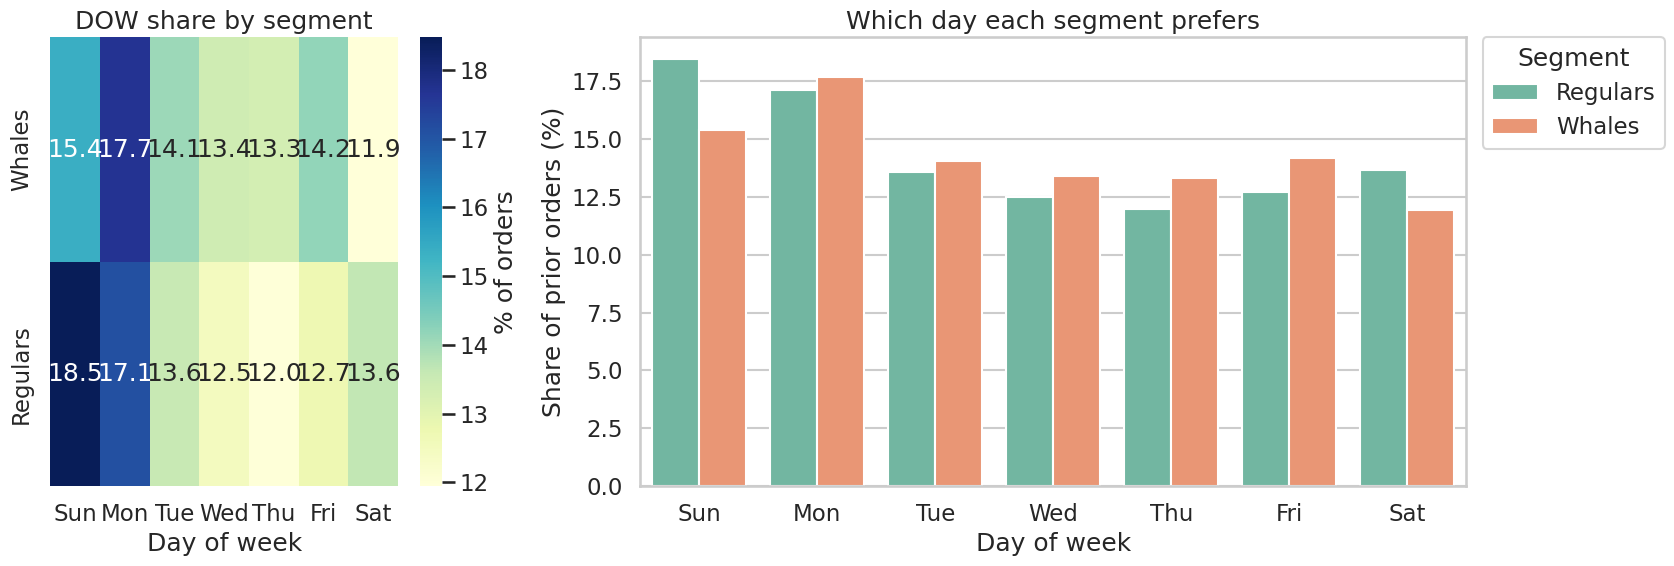

,segment,day_name,share_pct
0,Regulars,Sun,18.47
1,Whales,Mon,17.67


Key DOW signal:
- Regulars: peak day = Sun (18.5% of prior orders)
- Whales: peak day = Mon (17.7% of prior orders)

15-day danger signal:


,segment,customers,median_last_gap,at_risk_15_share
1,Whales,20644,6.00,9.13
0,Regulars,185565,18.00,53.68


Interpretation: If a segment's natural cadence is short but the latest gap drifts beyond 15 days, that customer is a good candidate for replenishment nudges or win-back offers.


In [6]:
dow_map = {0: "Sun", 1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"}
dow_order = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

dow_mix = prior_orders.groupby(["segment", "order_dow"]).size().rename("orders").reset_index()
dow_mix["segment_total"] = dow_mix.groupby("segment")["orders"].transform("sum")
dow_mix["share_pct"] = dow_mix["orders"] / dow_mix["segment_total"] * 100
dow_mix["day_name"] = pd.Categorical(
    dow_mix["order_dow"].map(dow_map),
    categories=dow_order,
    ordered=True,
)

dow_pivot = dow_mix.pivot(index="segment", columns="day_name", values="share_pct").reindex(
    index=["Whales", "Regulars"],
    columns=dow_order,
)

fig, axes = plt.subplots(1, 2, figsize=(19, 6), gridspec_kw={"width_ratios": [1, 1.9]})
sns.heatmap(dow_pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "% of orders"})
axes[0].set_title("DOW share by segment")
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("")

sns.barplot(
    data=dow_mix.sort_values(["day_name", "segment"]),
    x="day_name",
    y="share_pct",
    hue="segment",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Which day each segment prefers")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Share of prior orders (%)")
axes[1].legend(
    title="Segment",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    frameon=True,
    borderaxespad=0,
)
fig.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

favorite_days = (
    dow_mix.sort_values(["segment", "share_pct"], ascending=[True, False])
    .groupby("segment")
    .head(1)
    [["segment", "day_name", "share_pct"]]
    .reset_index(drop=True)
)

display(favorite_days)

print("Key DOW signal:")
for row in favorite_days.itertuples(index=False):
    print(f"- {row.segment}: peak day = {row.day_name} ({row.share_pct:.1f}% of prior orders)")

risk_snapshot = segment_summary[["segment", "customers", "median_last_gap", "at_risk_15_share"]].copy()
print("\n15-day danger signal:")
display(risk_snapshot)
print(
    "Interpretation: If a segment's natural cadence is short but the latest gap drifts beyond 15 days, "
    "that customer is a good candidate for replenishment nudges or win-back offers."
)

## 2) Order Sequence / Customer Tenure: จากตะกร้าแรกสู่พฤติกรรมของ Whales

แทนการดู `month` เราจะดูว่าเมื่อ order progression เดินหน้าไป (`1st`, `2-5`, `6-10`, `11-20`, `21+`) ส่วนผสมของสินค้าเปลี่ยนไปอย่างไร

สิ่งที่อยากจับให้ได้:
- สินค้าไหนทำหน้าที่เป็น **ประตูหน้าบ้าน** (*first-purchase items*)
- สินค้าไหนเริ่มโตขึ้นเมื่อ user กลายเป็นลูกค้าประจำหรือ `Whales`

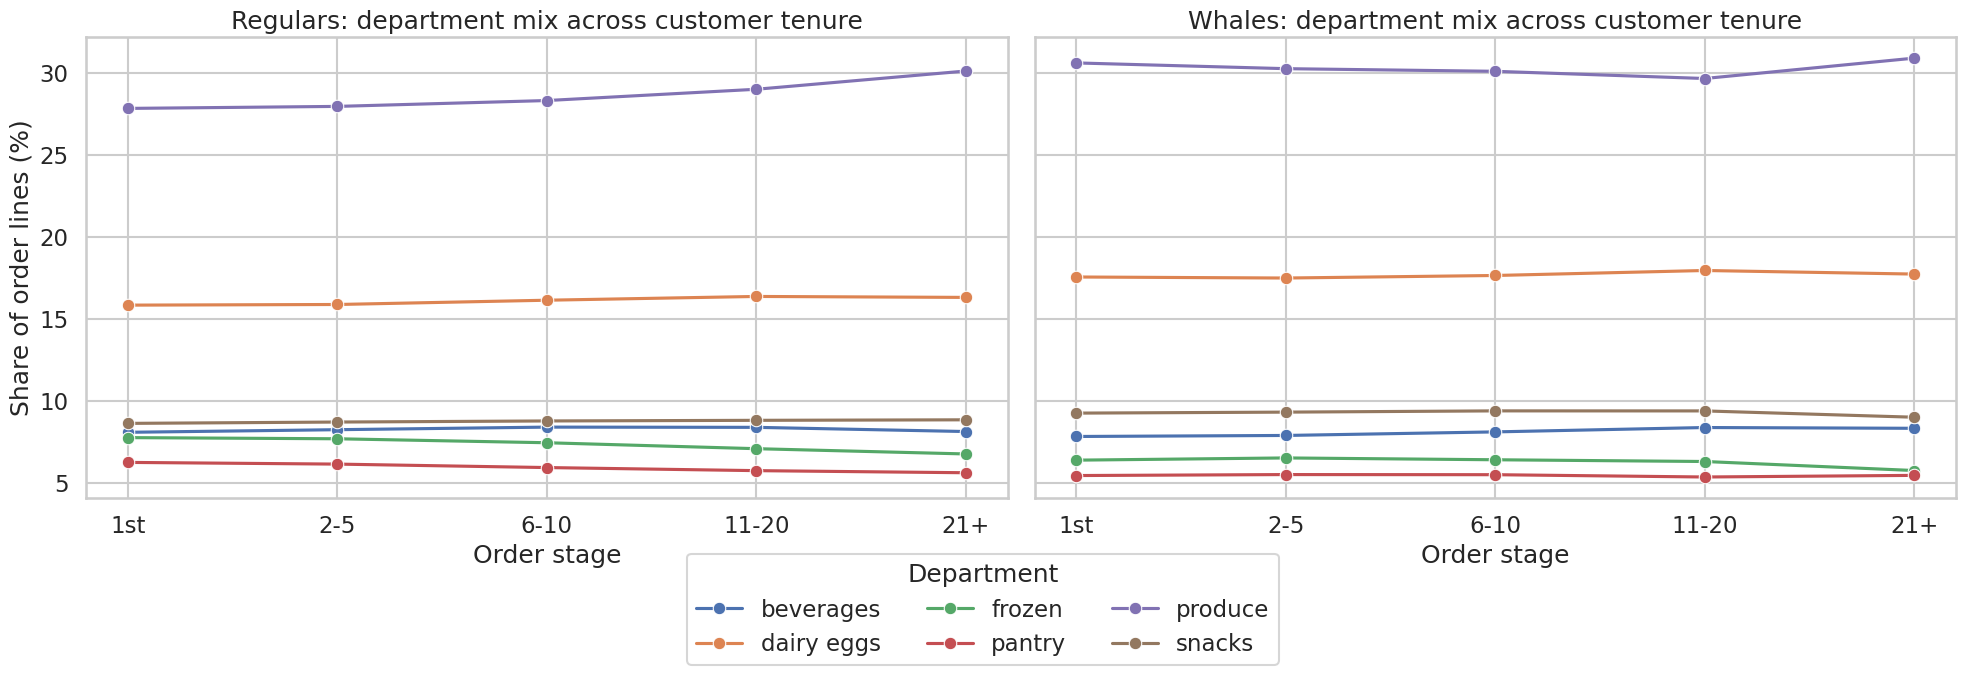

,segment,department,first_share,late_share,delta_pct_pt
0,Regulars,produce,27.82,30.09,2.28
1,Regulars,dairy eggs,15.84,16.31,0.47
2,Regulars,babies,1.02,1.37,0.35
3,Regulars,missing,0.12,0.43,0.31
4,Regulars,snacks,8.64,8.85,0.22
5,Regulars,beverages,8.09,8.14,0.05
6,Regulars,bulk,0.08,0.11,0.03
7,Regulars,other,0.12,0.12,0.01
8,Whales,beverages,7.84,8.34,0.50
9,Whales,produce,30.59,30.88,0.29


Top first-purchase items by segment:


,segment,product_name,order_lines
0,Regulars,Banana,25968
1,Regulars,Bag of Organic Bananas,16625
2,Regulars,Organic Strawberries,13647
3,Regulars,Organic Baby Spinach,13177
4,Regulars,Organic Avocado,12930
5,Regulars,Organic Hass Avocado,9517
6,Regulars,Strawberries,7858
7,Regulars,Large Lemon,7664
8,Regulars,Limes,7630
9,Regulars,Cucumber Kirby,6107


Products that gain share when Whales become mature shoppers:


,product_name,first_share,late_share,delta_pct_pt
0,Bag of Organic Bananas,1.11,1.51,0.40
1,Organic Raspberries,0.41,0.60,0.19
2,Large Lemon,0.30,0.49,0.18
3,Apple Honeycrisp Organic,0.28,0.41,0.14
4,Organic Yellow Onion,0.30,0.43,0.12
5,Strawberries,0.35,0.46,0.11
6,Organic Hass Avocado,0.70,0.80,0.11
7,Organic Gala Apples,0.23,0.31,0.08
8,Organic Large Extra Fancy Fuji Apple,0.25,0.32,0.06
9,Organic Fuji Apple,0.25,0.30,0.05


In [8]:
# Build lookup tables explicitly so this section works with the direct-import setup
product_lookup = (
    tables["products"][["product_id", "product_name", "department_id"]]
    .drop_duplicates("product_id")
    .copy()
)
departments = (
    tables["departments"][["department_id", "department"]]
    .drop_duplicates("department_id")
    .copy()
)
department_lookup = product_lookup.merge(
    departments,
    on="department_id",
    how="left",
    validate="many_to_one",
)[["product_id", "department"]]

stage_dept = (
    prior_base.merge(
        product_lookup[["product_id", "product_name", "department_id"]],
        on="product_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        departments,
        on="department_id",
        how="left",
        validate="many_to_one",
    )
)

stage_mix = (
    stage_dept.groupby(["segment", "stage", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
stage_mix["stage_total"] = stage_mix.groupby(["segment", "stage"])["order_lines"].transform("sum")
stage_mix["share_pct"] = stage_mix["order_lines"] / stage_mix["stage_total"] * 100

focus_departments = ["produce", "dairy eggs", "snacks", "beverages", "frozen", "pantry"]
plot_stage_mix = stage_mix[stage_mix["department"].isin(focus_departments)].copy()

fig, axes = plt.subplots(1, 2, figsize=(20, 6.8), sharey=True)
for ax, seg in zip(axes, ["Regulars", "Whales"]):
    sns.lineplot(
        data=plot_stage_mix[plot_stage_mix["segment"] == seg],
        x="stage",
        y="share_pct",
        hue="department",
        marker="o",
        ax=ax,
    )
    ax.set_title(f"{seg}: department mix across customer tenure")
    ax.set_xlabel("Order stage")
    ax.set_ylabel("Share of order lines (%)")

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(
    handles,
    labels,
    title="Department",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=True,
)
fig.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

first_stage = stage_mix[stage_mix["stage"] == "1st"][["segment", "department", "share_pct"]].rename(columns={"share_pct": "first_share"})
late_stage = stage_mix[stage_mix["stage"] == "21+"][["segment", "department", "share_pct"]].rename(columns={"share_pct": "late_share"})
dept_shift = first_stage.merge(late_stage, on=["segment", "department"], how="inner")
dept_shift["delta_pct_pt"] = dept_shift["late_share"] - dept_shift["first_share"]

display(
    dept_shift.sort_values(["segment", "delta_pct_pt"], ascending=[True, False])
    .groupby("segment")
    .head(8)
    .reset_index(drop=True)
)

first_items = (
    stage_dept.loc[stage_dept["order_number"] == 1]
    .groupby(["segment", "product_name"])
    .size()
    .rename("order_lines")
    .reset_index()
)
first_items["rank_in_segment"] = first_items.groupby("segment")["order_lines"].rank(method="first", ascending=False)
first_items_top = first_items[first_items["rank_in_segment"] <= 10].sort_values(["segment", "rank_in_segment"])

whale_product_mix = (
    stage_dept.loc[stage_dept["segment"] == "Whales"]
    .groupby(["stage", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
whale_product_mix["stage_total"] = whale_product_mix.groupby("stage")["order_lines"].transform("sum")
whale_product_mix["share_pct"] = whale_product_mix["order_lines"] / whale_product_mix["stage_total"] * 100

whale_first = whale_product_mix[(whale_product_mix["stage"] == "1st") & (whale_product_mix["order_lines"] >= 500)][["product_name", "share_pct"]].rename(columns={"share_pct": "first_share"})
whale_late = whale_product_mix[(whale_product_mix["stage"] == "21+") & (whale_product_mix["order_lines"] >= 5000)][["product_name", "share_pct"]].rename(columns={"share_pct": "late_share"})
whale_lift = whale_first.merge(whale_late, on="product_name", how="inner")
whale_lift["delta_pct_pt"] = whale_lift["late_share"] - whale_lift["first_share"]
whale_lift = whale_lift.sort_values("delta_pct_pt", ascending=False)

print("Top first-purchase items by segment:")
display(first_items_top[["segment", "product_name", "order_lines"]].reset_index(drop=True))

print("Products that gain share when Whales become mature shoppers:")
display(whale_lift[["product_name", "first_share", "late_share", "delta_pct_pt"]].head(12).reset_index(drop=True))

## 3) Inter-order Cycle: รอบการหมุนเวียนของการซื้อซ้ำ

ส่วนนี้จะสร้าง **relative day index** ของแต่ละ user จาก `days_since_prior_order` เพื่อวัดว่า:
- หมวดไหนมีรอบซื้อซ้ำสั้น/ยาว
- สินค้าอย่าง **milk** มี cadence กี่วัน
- ถ้าลูกค้าปล่อย gap เกิน **15 วัน** เราควรตีความเป็นสัญญาณเตือนแบบไหน

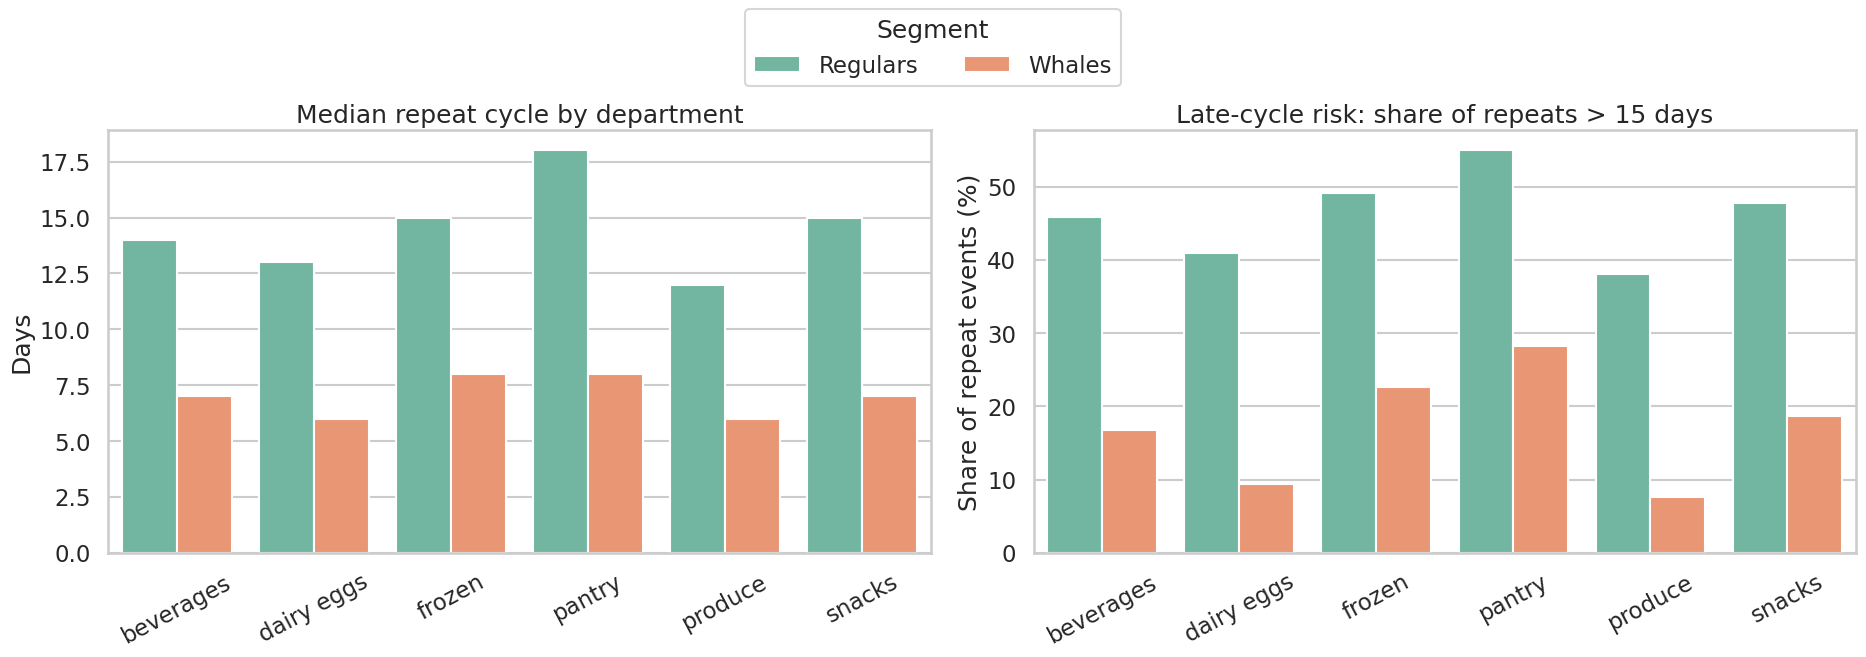

Department cycle summary:


,segment,department,repeat_events,median_cycle_days,p75_cycle_days,late_share_gt15
0,Regulars,produce,1332805,12.00,23.00,38.09
1,Regulars,dairy eggs,1195291,13.00,26.00,40.87
2,Regulars,beverages,788710,14.00,29.00,45.85
3,Regulars,snacks,731532,15.00,30.00,47.72
4,Regulars,frozen,640854,15.00,30.00,49.12
5,Regulars,pantry,571672,18.00,30.00,54.94
6,Whales,produce,883278,6.00,8.00,7.56
7,Whales,dairy eggs,791482,6.00,9.00,9.43
8,Whales,beverages,495846,7.00,12.00,16.83
9,Whales,snacks,485696,7.00,13.00,18.75


Milk-related product cycles:


,product_name,repeat_events,median_cycle_days,p75_cycle_days,late_share_gt15
0,Organic Whole Milk,113657,10.00,21.00,32.90
1,Organic Unsweetened Almond Milk,43428,14.00,29.00,44.98
2,Organic Reduced Fat 2% Milk,38251,11.00,22.00,35.37
3,Unsweetened Almondmilk,37027,13.00,28.00,42.40
4,Organic Reduced Fat Milk,30145,9.00,19.00,30.75
5,2% Reduced Fat Milk,28435,13.00,24.00,38.28
6,Whole Milk,27418,11.00,22.00,35.30
7,Unsweetened Original Almond Breeze Almond Milk,24459,14.00,30.00,46.02
8,Organic Milk,22550,10.00,21.00,33.84
9,Vanilla Almond Breeze Almond Milk,22370,14.00,30.00,46.18


Actionable interpretation:
- Whales tend to repurchase fresh-core categories in ~6-8 days, so nudges should start before day 8-10.
- Regulars are materially slower; many categories cluster around ~12-18 days, so day 15 is a good escalation trigger.
- Current latest-gap risk already exceeds 15 days for 53.7% of Regulars vs 9.1% of Whales.


In [9]:
order_dept = (
    prior_base[["user_id", "segment", "order_id", "day_num", "product_id"]]
    .merge(department_lookup, on="product_id", how="left", validate="many_to_one")
    [["user_id", "segment", "order_id", "day_num", "department"]]
    .drop_duplicates()
    .sort_values(["user_id", "department", "day_num"])
)
order_dept["dept_cycle_days"] = order_dept.groupby(["user_id", "department"])["day_num"].diff()
dept_cycles = order_dept.dropna(subset=["dept_cycle_days"]).copy()

dept_cycle_stats = (
    dept_cycles.groupby(["segment", "department"], as_index=False)
    .agg(
        repeat_events=("dept_cycle_days", "size"),
        median_cycle_days=("dept_cycle_days", "median"),
        p75_cycle_days=("dept_cycle_days", lambda s: s.quantile(0.75)),
        late_share_gt15=("dept_cycle_days", lambda s: (s > 15).mean() * 100),
    )
)

department_focus = ["produce", "dairy eggs", "beverages", "snacks", "frozen", "pantry"]
dept_focus_stats = dept_cycle_stats[dept_cycle_stats["department"].isin(department_focus)].copy()

fig, axes = plt.subplots(1, 2, figsize=(19, 6.5))
sns.barplot(
    data=dept_focus_stats,
    x="department",
    y="median_cycle_days",
    hue="segment",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Median repeat cycle by department")
axes[0].set_xlabel("")
axes[0].set_ylabel("Days")
axes[0].tick_params(axis="x", rotation=28)

sns.barplot(
    data=dept_focus_stats,
    x="department",
    y="late_share_gt15",
    hue="segment",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Late-cycle risk: share of repeats > 15 days")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share of repeat events (%)")
axes[1].tick_params(axis="x", rotation=28)

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(handles, labels, title="Segment", loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=True)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

product_events = (
    prior_base[["user_id", "product_id", "day_num"]]
    .drop_duplicates()
    .sort_values(["user_id", "product_id", "day_num"])
)
product_events["product_cycle_days"] = product_events.groupby(["user_id", "product_id"])["day_num"].diff()
product_cycles = product_events.dropna(subset=["product_cycle_days"]).copy()

product_cycle_stats = (
    product_cycles.groupby("product_id", as_index=False)
    .agg(
        repeat_events=("product_cycle_days", "size"),
        median_cycle_days=("product_cycle_days", "median"),
        p75_cycle_days=("product_cycle_days", lambda s: s.quantile(0.75)),
        late_share_gt15=("product_cycle_days", lambda s: (s > 15).mean() * 100),
    )
    .merge(product_lookup[["product_id", "product_name"]], on="product_id", how="left")
)

milk_focus = (
    product_cycle_stats[
        product_cycle_stats["product_name"].str.contains("milk", case=False, na=False)
        & (product_cycle_stats["repeat_events"] >= 5_000)
    ]
    .sort_values("repeat_events", ascending=False)
    .head(12)
)

print("Department cycle summary:")
display(
    dept_focus_stats.sort_values(["segment", "median_cycle_days", "repeat_events"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("Milk-related product cycles:")
display(milk_focus[["product_name", "repeat_events", "median_cycle_days", "p75_cycle_days", "late_share_gt15"]].reset_index(drop=True))

regular_gap = segment_summary.loc[segment_summary["segment"] == "Regulars", "at_risk_15_share"].iloc[0]
whale_gap = segment_summary.loc[segment_summary["segment"] == "Whales", "at_risk_15_share"].iloc[0]

print("Actionable interpretation:")
print(f"- Whales tend to repurchase fresh-core categories in ~6-8 days, so nudges should start before day 8-10.")
print(f"- Regulars are materially slower; many categories cluster around ~12-18 days, so day 15 is a good escalation trigger.")
print(f"- Current latest-gap risk already exceeds 15 days for {regular_gap:.1f}% of Regulars vs {whale_gap:.1f}% of Whales.")

## 4) DOW Deep Dive: Basket Intensity, Weekend Warriors, and Category Boom

จากเดิมที่ดูแค่ว่า segment ไหนซื้อวันไหน ส่วนนี้จะเจาะลึกว่า **"ตะกร้าแน่นแค่ไหน"** และ **"หมวดสินค้าไหนบูมในวันอะไร"**

สิ่งที่ต้องตอบให้ได้:
- ใครคือ **Weekend Stockers** และใครเป็น **Weekday Re-fillers**
- วันไหนที่ลูกค้าใส่สินค้า **หลากหลาย category** มากเป็นพิเศษ
- หมวดอย่าง `produce`, `snacks`, `beverages`, `pantry` มี **day-of-week signature** ของตัวเองหรือไม่

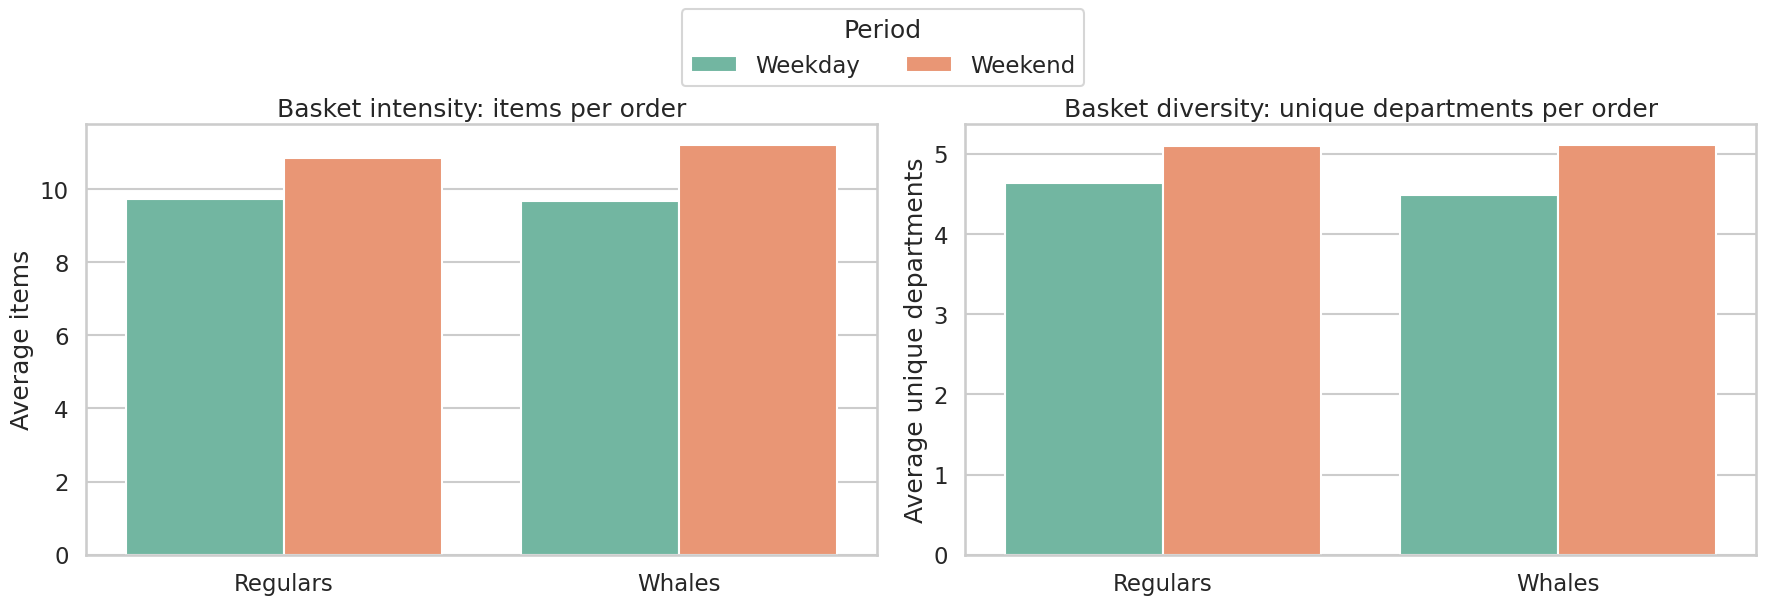

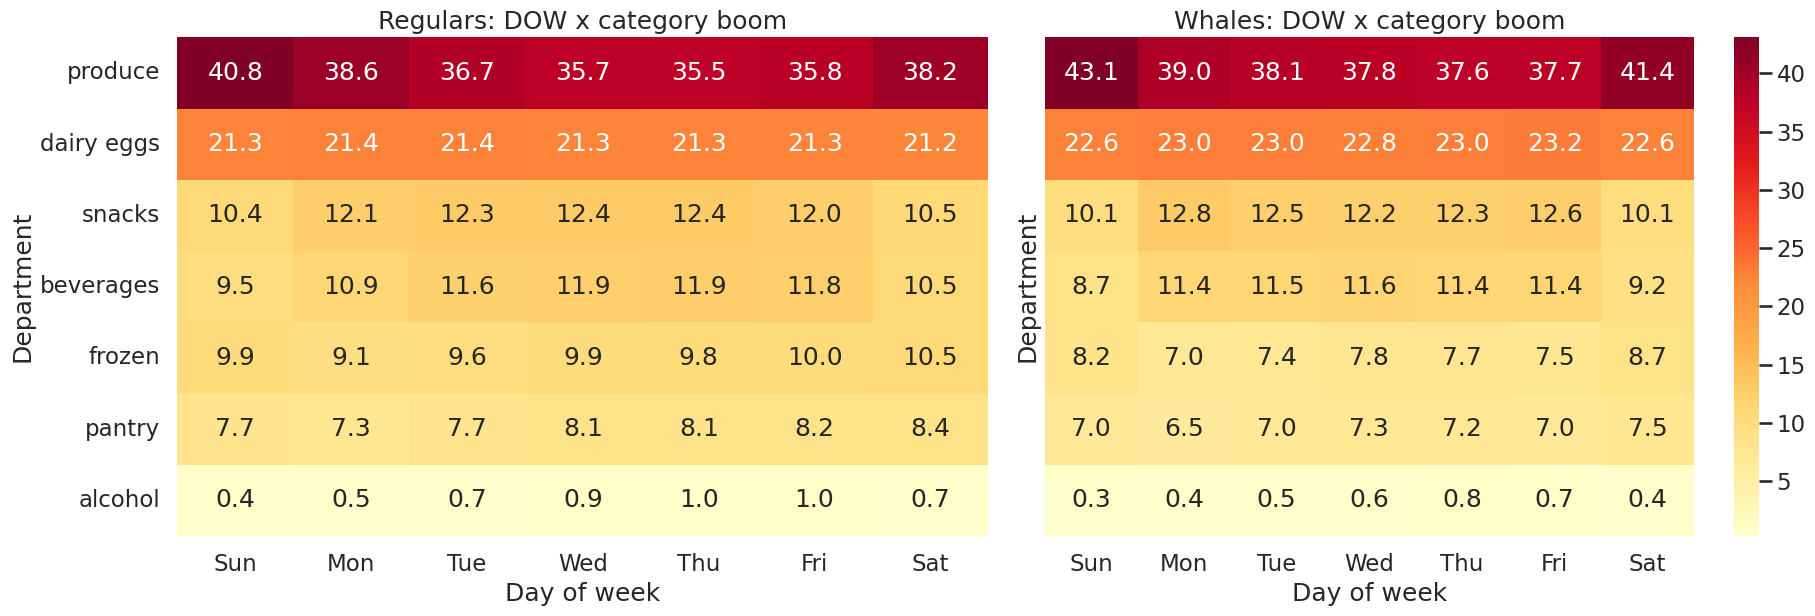

Weekend vs Weekday Warriors:


period,segment,Weekday,Weekend,weekend_lift_pct,shopping_style
0,Regulars,9.73,10.85,11.49,Balanced / refill-driven
1,Whales,9.67,11.21,15.99,Weekend Stockers


- Regulars: Balanced / refill-driven | weekend basket lift = 11.5% vs weekday
- Whales: Weekend Stockers | weekend basket lift = 16.0% vs weekday

Peak day by category:


,segment,department,day_name,share_pct
0,Regulars,alcohol,Thu,0.99
1,Regulars,beverages,Thu,11.94
2,Regulars,dairy eggs,Tue,21.43
3,Regulars,frozen,Sat,10.51
4,Regulars,pantry,Sat,8.42
5,Regulars,produce,Sun,40.82
6,Regulars,snacks,Wed,12.38
7,Whales,alcohol,Thu,0.76
8,Whales,beverages,Wed,11.60
9,Whales,dairy eggs,Fri,23.20


Organic-share days (proxy for premium/healthy intent):


,segment,order_dow,organic_share_pct,day_name
0,Regulars,0,30.90,Sun
1,Regulars,1,29.97,Mon
2,Regulars,6,29.08,Sat
3,Whales,0,38.56,Sun
4,Whales,6,37.13,Sat
5,Whales,1,35.11,Mon


Action idea: use Sunday for fresh/produce pushes, Saturday for frozen/pantry readiness, and mid-week to late-week flash offers for snacks/beverages where the category share peaks.


In [10]:
basket_intensity = (
    stage_dept.groupby(["order_id", "segment", "order_dow"], as_index=False)
    .agg(
        items=("product_id", "size"),
        unique_skus=("product_id", "nunique"),
        unique_departments=("department", "nunique"),
    )
)
basket_intensity["period"] = np.where(
    basket_intensity["order_dow"].isin([0, 6]),
    "Weekend",
    "Weekday",
)

basket_summary = (
    basket_intensity.groupby(["segment", "period"], as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_items=("items", "mean"),
        avg_unique_skus=("unique_skus", "mean"),
        avg_unique_departments=("unique_departments", "mean"),
    )
)

warrior_view = basket_summary.pivot(index="segment", columns="period", values="avg_items")
warrior_view["weekend_lift_pct"] = (warrior_view["Weekend"] / warrior_view["Weekday"] - 1) * 100
warrior_view["shopping_style"] = np.where(
    warrior_view["weekend_lift_pct"] >= 14,
    "Weekend Stockers",
    "Balanced / refill-driven",
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=basket_summary, x="segment", y="avg_items", hue="period", palette="Set2", ax=axes[0])
axes[0].set_title("Basket intensity: items per order")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average items")

sns.barplot(
    data=basket_summary,
    x="segment",
    y="avg_unique_departments",
    hue="period",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Basket diversity: unique departments per order")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average unique departments")

handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(handles, labels, title="Period", loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=True)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

focus_dow_departments = ["produce", "dairy eggs", "snacks", "beverages", "frozen", "pantry", "alcohol"]
day_category_mix = (
    stage_dept[stage_dept["department"].isin(focus_dow_departments)]
    .groupby(["segment", "order_dow", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
day_category_mix["day_total"] = day_category_mix.groupby(["segment", "order_dow"])["order_lines"].transform("sum")
day_category_mix["share_pct"] = day_category_mix["order_lines"] / day_category_mix["day_total"] * 100
day_category_mix["day_name"] = pd.Categorical(
    day_category_mix["order_dow"].map(dow_map),
    categories=dow_order,
    ordered=True,
)

fig, axes = plt.subplots(1, 2, figsize=(19, 6.5), sharey=True)
for ax, seg in zip(axes, ["Regulars", "Whales"]):
    heat = (
        day_category_mix[day_category_mix["segment"] == seg]
        .pivot(index="department", columns="day_name", values="share_pct")
        .reindex(focus_dow_departments)
    )
    sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar=ax is axes[-1])
    ax.set_title(f"{seg}: DOW x category boom")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Department")
fig.tight_layout()
plt.show()

stage_dept["is_organic"] = stage_dept["product_name"].str.contains("Organic", case=False, na=False)
organic_by_day = (
    stage_dept.groupby(["segment", "order_dow"], observed=False)["is_organic"]
    .mean()
    .mul(100)
    .rename("organic_share_pct")
    .reset_index()
)
organic_by_day["day_name"] = organic_by_day["order_dow"].map(dow_map)
peak_day_by_category = (
    day_category_mix.sort_values(["segment", "department", "share_pct"], ascending=[True, True, False])
    .groupby(["segment", "department"])
    .head(1)
    [["segment", "department", "day_name", "share_pct"]]
    .reset_index(drop=True)
)

print("Weekend vs Weekday Warriors:")
display(warrior_view.reset_index())
for row in warrior_view.reset_index().itertuples(index=False):
    print(f"- {row.segment}: {row.shopping_style} | weekend basket lift = {row.weekend_lift_pct:.1f}% vs weekday")

print("\nPeak day by category:")
display(peak_day_by_category)

print("Organic-share days (proxy for premium/healthy intent):")
display(organic_by_day.sort_values(["segment", "organic_share_pct"], ascending=[True, False]).groupby("segment").head(3).reset_index(drop=True))

print(
    "Action idea: use Sunday for fresh/produce pushes, Saturday for frozen/pantry readiness, "
    "and mid-week to late-week flash offers for snacks/beverages where the category share peaks."
)

## 5) Advanced Customer Journey: Gateway Products, Habit Products, and Last-Order Warning

ส่วนนี้คือ behavioral deep dive ตามลำดับการสั่งซื้อจริง:

- **Gateway Products**: สินค้าที่พาลูกค้าเข้ามาในช่วง `order 1-2`
- **Habit Products**: สินค้าที่ share โตขึ้นเมื่อ journey ไปถึง `21+` orders
- **Last Orders Signal**: ในตะกร้าสุดท้ายก่อนเกิด gap เกิน `15 วัน` หมวดไหนเริ่มหายไป และหมวดไหนยังเหลืออยู่

> หมายเหตุ: สัญญาณ "last order" ในส่วนนี้ใช้ **last observable prior basket** เป็น proxy ของพฤติกรรมก่อนเสี่ยง churn เพราะ line-item detail อยู่ครบที่สุดใน `prior` orders

/tmp/ipykernel_1684814/2413344711.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1684814/2413344711.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


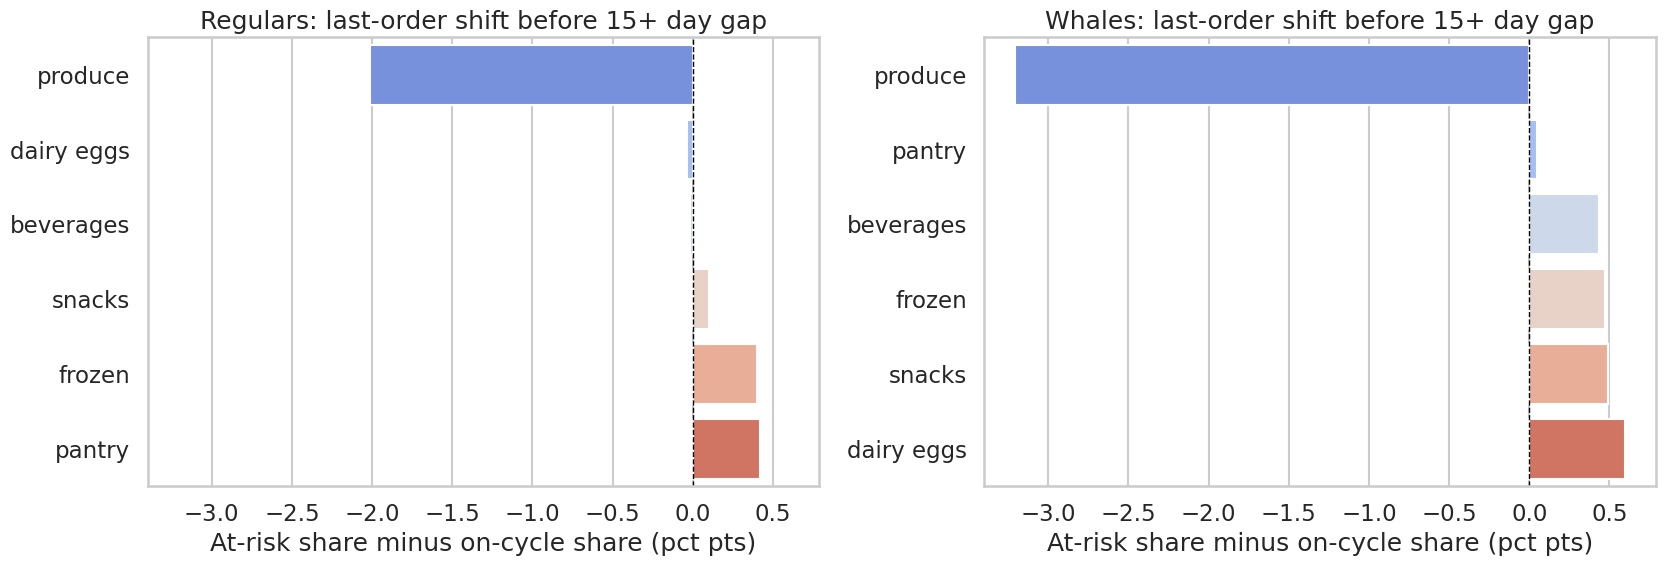

Gateway products (orders 1-2):


,segment,product_name,order_lines
0,Regulars,Banana,51606
1,Regulars,Bag of Organic Bananas,33471
2,Regulars,Organic Strawberries,26975
3,Regulars,Organic Baby Spinach,26196
4,Regulars,Organic Avocado,24705
5,Regulars,Organic Hass Avocado,19020
6,Regulars,Strawberries,15773
7,Regulars,Large Lemon,15576
8,Regulars,Limes,15362
9,Regulars,Cucumber Kirby,12407


Habit products (share grows by the time customers reach 21+ orders):


,segment,product_name,gateway_share,habit_share,delta_habit_minus_gateway
0,Regulars,Bag of Organic Bananas,0.91,1.29,0.38
1,Regulars,Organic Raspberries,0.30,0.48,0.18
2,Regulars,Organic Zucchini,0.24,0.39,0.15
3,Regulars,Large Lemon,0.42,0.56,0.14
4,Regulars,Organic Hass Avocado,0.52,0.64,0.13
5,Regulars,Organic Large Extra Fancy Fuji Apple,0.16,0.26,0.10
6,Regulars,Organic Whole Milk,0.33,0.42,0.10
7,Regulars,Organic Red Onion,0.17,0.27,0.09
8,Regulars,Apple Honeycrisp Organic,0.19,0.29,0.09
9,Regulars,Organic Gala Apples,0.16,0.24,0.08


Last-order warning signal by department:


risk_band,segment,department,At-Risk (15+ days),On-cycle,delta_at_risk_minus_on_cycle
0,Regulars,produce,27.90,29.91,-2.01
1,Regulars,dairy eggs,15.57,15.60,-0.03
2,Regulars,beverages,8.23,8.25,-0.02
3,Regulars,snacks,8.63,8.53,0.10
4,Regulars,frozen,7.65,7.25,0.40
5,Regulars,pantry,6.19,5.77,0.42
6,Whales,produce,29.00,32.20,-3.21
7,Whales,pantry,5.31,5.26,0.05
8,Whales,beverages,8.68,8.24,0.44
9,Whales,frozen,6.34,5.86,0.47


- Regulars: produce share drops 2.01 pct pts in at-risk last baskets.
- Whales: produce share drops 3.21 pct pts in at-risk last baskets.
Interpretation: when the final observable basket shifts away from fresh-core categories and toward pantry/frozen/snack items, it can be used as an early churn-warning feature for CRM or retention models.


In [11]:
journey_base = stage_dept.copy()
journey_base["journey_stage"] = pd.cut(
    journey_base["order_number"],
    bins=[0, 2, 5, 10, 20, 10_000],
    labels=["1-2", "3-5", "6-10", "11-20", "21+"],
    include_lowest=True,
)

gateway_products = (
    journey_base.loc[journey_base["order_number"] <= 2]
    .groupby(["segment", "product_name"])
    .size()
    .rename("order_lines")
    .reset_index()
)
gateway_products["rank_in_segment"] = gateway_products.groupby("segment")["order_lines"].rank(method="first", ascending=False)
gateway_top = gateway_products[gateway_products["rank_in_segment"] <= 10].sort_values(["segment", "rank_in_segment"])

journey_product_mix = (
    journey_base.groupby(["segment", "journey_stage", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
journey_product_mix["stage_total"] = journey_product_mix.groupby(["segment", "journey_stage"])["order_lines"].transform("sum")
journey_product_mix["share_pct"] = journey_product_mix["order_lines"] / journey_product_mix["stage_total"] * 100

gateway_share = journey_product_mix[
    (journey_product_mix["journey_stage"] == "1-2") & (journey_product_mix["order_lines"] >= 500)
][["segment", "product_name", "share_pct"]].rename(columns={"share_pct": "gateway_share"})
habit_share = journey_product_mix[
    (journey_product_mix["journey_stage"] == "21+") & (journey_product_mix["order_lines"] >= 5_000)
][["segment", "product_name", "share_pct"]].rename(columns={"share_pct": "habit_share"})

habit_lift = gateway_share.merge(habit_share, on=["segment", "product_name"], how="inner")
habit_lift["delta_habit_minus_gateway"] = habit_lift["habit_share"] - habit_lift["gateway_share"]
habit_lift = habit_lift.sort_values(["segment", "delta_habit_minus_gateway"], ascending=[True, False])

last_prior_proxy = prior_orders.sort_values(["user_id", "order_number"]).groupby("user_id").tail(1).copy()
last_prior_proxy = last_prior_proxy.merge(customer_profile[["user_id", "last_gap"]], on="user_id", how="left", validate="one_to_one")
last_prior_proxy["risk_band"] = np.where(last_prior_proxy["last_gap"] > 15, "At-Risk (15+ days)", "On-cycle")

last_order_lines = journey_base.merge(
    last_prior_proxy[["order_id", "user_id", "segment", "risk_band"]],
    on=["order_id", "user_id", "segment"],
    how="inner",
    validate="many_to_one",
)
last_order_mix = (
    last_order_lines.groupby(["segment", "risk_band", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
last_order_mix["band_total"] = last_order_mix.groupby(["segment", "risk_band"])["order_lines"].transform("sum")
last_order_mix["share_pct"] = last_order_mix["order_lines"] / last_order_mix["band_total"] * 100

last_order_delta = (
    last_order_mix[last_order_mix["department"].isin(["produce", "dairy eggs", "snacks", "beverages", "frozen", "pantry"])]
    .pivot_table(index=["segment", "department"], columns="risk_band", values="share_pct")
    .dropna()
    .reset_index()
)
last_order_delta["delta_at_risk_minus_on_cycle"] = (
    last_order_delta["At-Risk (15+ days)"] - last_order_delta["On-cycle"]
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6), sharex=True)
for ax, seg in zip(axes, ["Regulars", "Whales"]):
    plot_df = last_order_delta[last_order_delta["segment"] == seg].sort_values("delta_at_risk_minus_on_cycle")
    sns.barplot(
        data=plot_df,
        x="delta_at_risk_minus_on_cycle",
        y="department",
        palette="coolwarm",
        ax=ax,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{seg}: last-order shift before 15+ day gap")
    ax.set_xlabel("At-risk share minus on-cycle share (pct pts)")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("Gateway products (orders 1-2):")
display(gateway_top[["segment", "product_name", "order_lines"]].reset_index(drop=True))

print("Habit products (share grows by the time customers reach 21+ orders):")
display(habit_lift.groupby("segment").head(12).reset_index(drop=True))

print("Last-order warning signal by department:")
display(last_order_delta.sort_values(["segment", "delta_at_risk_minus_on_cycle"]).reset_index(drop=True))

fresh_drop = last_order_delta[last_order_delta["department"] == "produce"][["segment", "delta_at_risk_minus_on_cycle"]]
for row in fresh_drop.itertuples(index=False):
    print(f"- {row.segment}: produce share drops {abs(row.delta_at_risk_minus_on_cycle):.2f} pct pts in at-risk last baskets.")
print(
    "Interpretation: when the final observable basket shifts away from fresh-core categories and toward pantry/frozen/snack items, "
    "it can be used as an early churn-warning feature for CRM or retention models."
)

## 6) Portfolio Positioning: Why this is a true Deep Dive

คุณสามารถเล่าใน portfolio ได้ชัดเจนว่า notebook คนละมุมกัน:

- **Notebook ก่อนหน้า** → *Static Profiling*: ลูกค้าคือใคร, มูลค่าเท่าไร, ชอบอะไรโดยรวม
- **Notebook นี้** → *Behavioral Dynamics*: ลูกค้าเปลี่ยนพฤติกรรมอย่างไรตาม **วันในสัปดาห์**, **ลำดับการสั่งซื้อ**, และ **จังหวะการกลับมาซื้อซ้ำ**

ดังนั้นนี่ไม่ใช่การทำซ้ำ แต่เป็นการขุดลึกจากอีกมิติหนึ่งเพื่อหา **timing strategy**, **dynamic pricing**, **replenishment trigger**, และ **early churn signal**

## Executive takeaway

### สิ่งที่เห็นชัดจาก deep dive นี้
- **Whales คือ Weekend Stockers ชัดเจนกว่า**: basket size ช่วง weekend สูงกว่า weekday ราว **+16%** ขณะที่ `Regulars` ก็ใหญ่ขึ้นเช่นกันแต่เบากว่า (ประมาณ **+11.5%**)
- **DOW x Category Boom มีอยู่จริง**: `produce` พีควันอาทิตย์, `frozen`/`pantry` เด่นวันเสาร์, ส่วน `snacks` และ `beverages` มีจังหวะพีคในช่วงกลางถึงปลายสัปดาห์
- **Gateway basket = fresh staples**: `Banana`, `Organic Strawberries`, `Organic Baby Spinach`, `Organic Whole Milk` เป็นตัวดึงลูกค้าในช่วงแรก
- **Habit basket = premium routine**: เมื่อ journey โตขึ้น สินค้าอย่าง `Bag of Organic Bananas`, `Organic Raspberries`, `Large Lemon`, `Organic Yellow Onion` จะมี share สูงขึ้น
- **Last-order warning signal**: ก่อนเกิด gap เกิน `15 วัน` สัดส่วน `produce` ในตะกร้าสุดท้ายลดลงประมาณ **2.0 pct pts** ใน `Regulars` และ **3.2 pct pts** ใน `Whales` ซึ่งเป็น early signal ที่น่าสนใจมาก

### Business actions ที่เอาไปใช้ได้ทันที
1. **Dynamic pricing / Flash sale by day**: ดันโปร fresh ในวันอาทิตย์, โปร pantry/frozen ในวันเสาร์, และ snack/beverage offers ในช่วงกลาง-ปลายสัปดาห์
2. **Personalized notification timing**: ส่งเตือน `Whales` ก่อน weekend stock-up และยิงเตือน `Regulars` ในจังหวะ refill ระหว่างสัปดาห์
3. **Lifecycle CRM**: ใช้ gateway products สำหรับ onboarding แล้ว cross-sell habit products เมื่อ user เข้าสู่ช่วง `6-10` หรือ `11+` orders
4. **Churn prevention**: ถ้าพบว่าลูกค้าเริ่มซื้อของสดน้อยลงและ gap ขยับเกิน **15 วัน** ให้ถือเป็น trigger สำหรับ retention campaign